In [1]:
from bezierv.classes.distfit import DistFit
from bezierv.classes.bezierv import Bezierv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt

from scipy.optimize import brentq, bisect
from scipy.integrate import quad
from statsmodels.distributions.empirical_distribution import ECDF

# import arrays for type hinting
from numpy.typing import ArrayLike

class BeziervNoOrder:
    def __init__(self, 
                 n: int, 
                 controls_x: ArrayLike=None, 
                 controls_z: ArrayLike=None):
        """
        Initialize a Bezierv instance representing a Bezier random variable.

        This constructor initializes the Bezier curve with a given number of control points `n` and 
        optionally with provided control points for the x and z coordinates. If control points are not 
        provided, they are initialized as zero arrays. It also sets up auxiliary arrays for differences 
        (deltas) and binomial coefficients, and initializes moment attributes to NaN.

        Parameters
        ----------
        n : int
            The number of control points of the Bezier random variable.
        controls_x : array-like, optional
            The x-coordinates of the control points (length n+1). If None, a zero array is created.
        controls_z : array-like, optional
            The z-coordinates of the control points (length n+1). If None, a zero array is created.

        Attributes
        ----------
        n : int
            The number of control points of the Bezier random variables.
        deltas_x : np.array
            Differences between consecutive x control points.
        deltas_z : np.array
            Differences between consecutive z control points.
        comb : np.array
            Array of binomial coefficients (n).
        comb_minus : np.array
            Array of binomial coefficients (n - 1).
        support : tuple
            The support of the Bezier random variable (initialized as (-inf, inf)).
        controls_x : np.array
            x-coordinates of the control points.
        controls_z : np.array
            z-coordinates of the control points.
        mean : float
            The mean of the curve (initialized as np.inf).
        var : float
            The variance of the curve (initialized as np.inf).
        skew : float
            The skewness of the curve (initialized as np.inf).
        kurt : float
            The kurtosis of the curve (initialized as np.inf).
        """
        self.n = n
        self.deltas_x = np.zeros(n)
        self.deltas_z = np.zeros(n)
        self.comb = np.zeros(n + 1)
        self.comb_minus = np.zeros(n)
        self.support = (-np.inf, np.inf)

        if controls_x is None and controls_z is None:
            self.controls_x = np.zeros(n + 1)
            self.controls_z = np.zeros(n + 1)
        elif controls_x is not None and controls_z is not None:
            controls_x = np.asarray(controls_x, dtype=float)
            controls_z = np.asarray(controls_z, dtype=float)
            self.controls_x = controls_x
            self.controls_z = controls_z
            self.support = (controls_x[0], controls_x[-1])
        else:
            raise ValueError('Either all or none of the parameters controls_x and controls_y must be provided')

        self.mean = np.inf
        self.variance = np.inf
        self.skewness = np.inf
        self.kurtosis = np.inf

        self.combinations()
        self.deltas()

    def update_bezierv(self, 
                       controls_x: np.array, 
                       controls_z: np.array):
        """
        Update the control points for the Bezier curve, bounds and recalculate deltas.

        Parameters
        ----------
        controls_x : array-like
            The new x-coordinates of the control points.
        controls_z : array-like
            The new z-coordinates of the control points.

        Returns
        -------
        None
        """
        controls_x = np.asarray(controls_x, dtype=float)
        controls_z = np.asarray(controls_z, dtype=float)
        self._validate_lengths(controls_x, controls_z)
        self._validate_ordering(controls_x, controls_z)

        self.controls_x = controls_x
        self.controls_z = controls_z
        self.support = (controls_x[0], controls_x[-1])

        self.deltas()

    def combinations(self):
        """
        Compute and store binomial coefficients.
        """
        n = self.n
        for i in range(0, n + 1):
            self.comb[i] = math.comb(n, i)
            if i < n:
                self.comb_minus[i] = math.comb(n - 1, i)

    def deltas(self):
        """
        Compute the differences between consecutive control points.
        """
        n = self.n
        for i in range(n):
            self.deltas_x[i] = self.controls_x[i + 1] - self.controls_x[i]
            self.deltas_z[i] = self.controls_z[i + 1] - self.controls_z[i]

    def bernstein(self, t: float, i: int, combinations: np.array, n: int) -> float:
        """
        Compute the Bernstein basis polynomial value.

        Parameters
        ----------
        t : float
            The parameter value (in the interval [0, 1]).
        i : int
            The index of the Bernstein basis polynomial.
        combinations : np.array
            An array of binomial coefficients to use in the computation.
        n : int
            The degree for the Bernstein polynomial.

        Returns
        -------
        float
            The value of the Bernstein basis polynomial at t.
        """
        return combinations[i] * t**i * (1 - t)**(n - i)

    def poly_x(self, t: float, controls_x: np.array = None) -> float:
        """
        Evaluate the x-coordinate at a given t value.

        Parameters
        ----------
        t : float
            The parameter value at which to evaluate (in [0, 1]).
        controls_x : np.array, optional
            An array of control points for the x-coordinate. Defaults to self.controls_x.

        Returns
        -------
        float
            The evaluated x-coordinate at t.
        """
        if controls_x is None:
            self._ensure_initialized()
            controls_x = self.controls_x
        n = self.n
        p_x = 0
        for i in range(n + 1):
           p_x  += self.bernstein(t, i, self.comb, self.n) * controls_x[i]
        return p_x

    def poly_z(self, t: float, controls_z: np.array = None) -> float:
        """
        Evaluate the z-coordinate at a given t value.

        Parameters
        ----------
        t : float
            The parameter value at which to evaluate the curve (typically in [0, 1]).
        controls_z : np.array, optional
            An array of control points for the z-coordinate. Defaults to self.controls_z.

        Returns
        -------
        float
            The evaluated z-coordinate at t.
        """
        if controls_z is None:
            self._ensure_initialized()
            controls_z = self.controls_z
        n = self.n
        p_z = 0
        for i in range(n + 1):
           p_z  += self.bernstein(t, i, self.comb, self.n) * controls_z[i]
        return p_z

    def root_find(self, x: float, method: str = 'brentq') -> float:
        """
        Find t such that the Bezier curve's x-coordinate equals a given value.

        This method solves for the root of the equation poly_x(t) - x = 0 using a specified root-finding
        algorithm. The search is performed in the interval [0, 1].

        Parameters
        ----------
        x : float
            The x-coordinate for which to find the corresponding parameter t.
        method : {'brentq', 'bisect'}, optional
            The root-finding method to use. Default is 'brentq'.

        Returns
        -------
        float
            The parameter t in the interval [0, 1] such that poly_x(t) is approximately equal to x.
        """
        self._ensure_initialized()
        def poly_x_zero(t, x):
            return self.poly_x(t) - x
        if method == 'brentq':
            t = brentq(poly_x_zero, 0, 1, args=(x,))
        elif method == 'bisect':
            t = bisect(poly_x_zero, 0, 1, args=(x,))
        return t

    def eval_t(self, t: float) -> tuple[float, float]:
        """
        Evaluate the CDF of the Bezier random variable at a given parameter value t.

        Parameters
        ----------
        t : float
            The parameter value at which to evaluate the curve (typically in [0, 1]).

        Returns
        -------
        tuple[float, float]
            A tuple containing the (x, z) coordinates of the point on the curve w.r.t. t.
        """
        self._ensure_initialized()
        n = self.n
        p_x = 0
        p_z = 0
        for i in range(n + 1):
            p_x += self.comb[i] * t**i * (1 - t)**(n - i) * self.controls_x[i]
            p_z += self.comb[i] * t**i * (1 - t)**(n - i) * self.controls_z[i]
        return p_x, p_z

    def eval_x(self, x: float) -> tuple[float, float]:
        """
        Evaluate the CDF of the Bezier random variable at a given x-coordinate.

        Parameters
        ----------
        x : float
            The x-coordinate at which to evaluate the Bezier curve.

        Returns
        -------
        tuple[float, float]
            A tuple containing the (x, z) coordinates of the point on the curve w.r.t. x.
        """
        self._ensure_initialized()
        t = self.root_find(x)
        return self.eval_t(t)

    def cdf_x(self, x: float) -> float:
        """
        Compute the cumulative distribution function (CDF) at a given x-coordinate.

        Parameters
        ----------
        x : float
            The x-coordinate at which to evaluate the CDF.

        Returns
        -------
        float
            The CDF value at the given x-coordinate.
        """
        self._ensure_initialized()
        if x < self.controls_x[0]:
            return 0
        if x > self.controls_x[-1]:
            return 1
        _, p_z = self.eval_x(x)
        return p_z

    def quantile(self, alpha: float, method: str = 'brentq') -> float:
        """
        Compute the quantile function (inverse CDF) for a given probability level alpha.

        Parameters
        ----------
        alpha : float
            The probability level for which to compute the quantile (in [0, 1]).

        Returns
        -------
        float
            The quantile value corresponding to the given alpha.
        """
        self._ensure_initialized()
        def cdf_t(t, alpha):
            return self.poly_z(t) - alpha
        
        if method == 'brentq':
            t = brentq(cdf_t, 0, 1, args=(alpha,))
        elif method == 'bisect':
            t = bisect(cdf_t, 0, 1, args=(alpha,))
        return self.poly_x(t)

    def pdf_t(self, t: float) -> float:
        """
        Compute the probability density function (PDF) of the Bezier random variable with respect to t.

        Parameters
        ----------
        t : float
            The value at which to compute the PDF (in [0, 1]).

        Returns
        -------
        float
            The computed PDF value at t.
        """
        self._ensure_initialized()
        n = self.n
        pdf_num_z = 0
        pdf_denom_x = 0
        for i in range(n):
            pdf_num_z += self.bernstein(t, i, self.comb_minus, n - 1) * self.deltas_z[i]
            pdf_denom_x += self.bernstein(t, i, self.comb_minus, n - 1) * self.deltas_x[i]
        return pdf_num_z/pdf_denom_x
    
    def pdf_x(self, x: float) -> float:
        """
        Compute the probability density function (PDF) of the Bezier random variable at a given x.

        Parameters
        ----------
        x : float
            The x-coordinate at which to evaluate the PDF.

        Returns
        -------
        float
            The computed PDF value at x.
        """
        self._ensure_initialized()
        t = self.root_find(x)
        return self.pdf_t(t)

    def pdf_numerator_t(self, t: float) -> float:
        """
        Compute the numerator part of the PDF for the Bezier random variable with respect to t.

        Parameters
        ----------
        t : float
            The value at which to compute the PDF numerator (in [0, 1]).

        Returns
        -------
        float
            The numerator of the PDF at t.
        """
        self._ensure_initialized()
        pdf_num_z = 0
        for i in range(self.n):
            pdf_num_z += self.bernstein(t, i, self.comb_minus, self.n - 1) * self.deltas_z[i]
        return pdf_num_z

    def get_mean(self, closed_form: bool=True) -> float:
        """
        Compute and return the mean of the distribution.

        Parameters
        ----------
        closed_form : bool, optional
            If True, use a closed-form solution for the mean. If False, compute it numerically (default is True).

        Returns
        -------
        float
            The mean value of the distribution.
        """
        self._ensure_initialized()
        if self.mean == np.inf:
            if closed_form:
                total = 0.0
                for ell in range(self.n + 1):
                    inner_sum = 0.0
                    for i in range(self.n):
                        denom = math.comb(2 * self.n - 1, ell + i)
                        inner_sum += (self.comb_minus[i] / denom) * self.deltas_z[i]
                    total += self.comb[ell] * self.controls_x[ell] * inner_sum
                self.mean = 0.5 * total
            else:
                a, b = self.bounds
                self.mean, _ = quad(lambda x: x * self.pdf_x(x), a, b) 
        return self.mean

    def get_variance(self) -> float:
        """Compute and return the variance of the distribution.

        Returns:
            float: The variance value of the distribution.
        """
        self._ensure_initialized()
        if self.variance == np.inf:
            a, b = self.support
            E_x2, _ = quad(lambda x: (x)**2 * self.pdf_x(x), a, b)
            if self.mean == np.inf:
                self.variance = E_x2 - self.get_mean()**2
            else:
                self.variance = E_x2 - self.mean**2
        return self.variance
    
    def get_skewness(self) -> float:
        """Compute and return the skewness of the distribution.

        Returns:
            float: The skewness value of the distribution.
        """
        self._ensure_initialized()
        if self.skewness == np.inf:
            a, b = self.support
            E_x3, _ = quad(lambda x: (x)**3 * self.pdf_x(x), a, b)
            mu = self.get_mean()
            sigma = math.sqrt(self.get_variance())
            self.skewness = (E_x3 - 3 * mu * sigma**2 - mu**3) / (sigma**3)
        return self.skewness

    def get_kurtosis(self) -> float:
        """Compute and return the kurtosis of the distribution.

        Returns:
            float: The kurtosis value of the distribution.
        """
        self._ensure_initialized()
        if self.kurtosis == np.inf:
            a, b = self.support
            E_x4, _ = quad(lambda x: (x)**4 * self.pdf_x(x), a, b)
            mu = self.get_mean()
            sigma = math.sqrt(self.get_variance())
            self.kurtosis = (E_x4 - 4 * mu * (E_x4 - 3 * mu * sigma**2 - mu**3) - 6 * mu**2 * sigma**2 - mu**4) / (sigma**4)
        return self.kurtosis
    
    def random(self, 
               n_sims: int,
               *,
               rng: np.random.Generator | int | None = None):
        """
        Generate random samples from the Bezier random variable.

        This method generates `n_sims` random samples from the Bezier random variable by evaluating
        the inverse CDF at uniformly distributed random values in the interval [0, 1].

        Parameters
        ----------
        n_sims : int
            The number of random samples to generate.
        rng : numpy.random.Generator | int | None, optional
            Pseudorandom-number generator state.  If *None* (default), a new
            ``numpy.random.Generator`` is created with fresh OS entropy.  Any
            value accepted by :func:`numpy.random.default_rng` (e.g. a seed
            integer or :class:`~numpy.random.SeedSequence`) is also allowed.


        Returns
        -------
        np.array
            An array of shape (n_sims,) containing the generated random samples from the Bezier random variable.
        """
        self._ensure_initialized()
        rng = np.random.default_rng(rng)
        u = rng.uniform(0, 1, n_sims)
        samples = np.zeros(n_sims)
        for i in range(n_sims):
            samples[i] = self.quantile(u[i])
        return samples


    def plot_cdf(self, data: np.array=None, num_points: int=100, ax: plt.Axes=None, show: bool=True):
        """
        Plot the cumulative distribution function (CDF) of the Bezier random variable alongside 
        the empirical CDF (if data is provided).

        Parameters
        ----------
        data : array-like, optional
            The data points at which to evaluate and plot the CDF. If None, a linspace is used.
        num_points : int, optional
            The number of points to use in the linspace when data is not provided (default is 100).
        ax : matplotlib.axes.Axes, optional
            The axes on which to plot the CDF. If None, the current axes are used.
        """
        self._ensure_initialized()
        data_bool = True
        if data is None:
            data_bool = False
            data = np.linspace(np.min(self.controls_x), np.max(self.controls_x), num_points)

        data = np.sort(data)
        x_bezier = np.zeros(len(data))
        cdf_x_bezier = np.zeros(len(data))

        for i in range(len(data)):
            p_x, p_z = self.eval_x(data[i])
            x_bezier[i] = p_x
            cdf_x_bezier[i] = p_z

        if ax is None:
            ax = plt.gca()

        if data_bool:
            ecdf_fn = ECDF(data)
            ax.plot(data, ecdf_fn(data), label='Empirical cdf', linestyle='--', color='black')

        ax.plot(x_bezier, cdf_x_bezier, label='Bezier cdf', linestyle='--')
        ax.scatter(self.controls_x, self.controls_z, label='Control Points', color='red')
        ax.legend()
        if show:
            plt.show()

    def plot_pdf(self, data: np.array=None, num_points: int=100, ax: plt.Axes=None, show: bool=True):
        """
        Plot the probability density function (PDF) of the Bezier random variable.

        Parameters
        ----------
        data : array-like, optional
            The data points at which to evaluate and plot the PDF. If None, a linspace is used.
        num_points : int, optional
            The number of points to use in the linspace when data is not provided (default is 100).
        ax : matplotlib.axes.Axes, optional
            The axes on which to plot the PDF. If None, the current axes are used.
        """
        self._ensure_initialized()
        if data is None:
            data = np.linspace(np.min(self.controls_x), np.max(self.controls_x), num_points)

        x_bezier = np.zeros(len(data))
        pdf_x_bezier = np.zeros(len(data))

        if ax is None:
            ax = plt.gca()

        for i in range(len(data)):
            p_x, _ = self.eval_x(data[i])
            x_bezier[i] = p_x
            pdf_x_bezier[i] = self.pdf_x(data[i])

        ax.plot(x_bezier, pdf_x_bezier, label='Bezier pdf', linestyle='-')
        ax.legend()
        if show:
            plt.show()

    def _validate_lengths(self, controls_x, controls_z):
        if len(controls_x) != len(controls_z):
            raise ValueError("controls_x and controls_z must have the same length.")
        if len(controls_x) != self.n + 1:
            raise ValueError(f"controls arrays must have length n+1 (= {self.n + 1}).")

    def _validate_ordering(self, controls_x, controls_z):
        if np.any(np.diff(controls_x) < 0):
            raise ValueError("controls_x must be nondecreasing.")
        if np.any(np.diff(controls_z) < 0):
            raise ValueError("controls_z must be nondecreasing.")

    def _ensure_initialized(self):
        if np.allclose(self.controls_x, 0) and np.allclose(self.controls_z, 0):
            raise RuntimeError(
                "Bezier controls are all zeros (placeholder). "
                "Provide valid controls in the constructor or call update_bezierv()."
            )
        
from bokeh.plotting import figure, curdoc
from bokeh.models import (ColumnDataSource, PointDrawTool, Button, CustomJS, 
                          DataTable, TableColumn, NumberFormatter, TapTool)
from bokeh.layouts import column, row

class InteractiveBezierv:
    """Manages an interactive Bezier distribution in a Bokeh plot."""
    
    def __init__(self, controls_x, controls_z):
        self._is_updating = False

        n = len(controls_x) - 1
        self.bezier = Bezierv(n=n, controls_x=controls_x, controls_z=controls_z)

        self.controls_source = ColumnDataSource(data=self._get_controls_data())
        self.curve_source = ColumnDataSource(data=self._get_curve_data())
        
        # Create CDF plot
        self.plot = figure(
            height=400, width=900,
            title="Interactive Bézier CDF Editor",
            x_axis_label="x", y_axis_label="CDF",
            y_range=(-0.05, 1.05)
        )
        
        self.plot.line(x='x', y='y', source=self.curve_source, line_width=3, legend_label="Bézier CDF", color="navy")
        self.plot.line(x='x', y='y', source=self.controls_source, line_dash="dashed", color="gray")
        
        controls_renderer = self.plot.scatter(
            x='x', y='y', source=self.controls_source, size=12,
            legend_label="Control Points", color="firebrick"
        )
        self.plot.legend.location = "top_left"

        draw_tool = PointDrawTool(renderers=[controls_renderer], add=True)
        self.plot.add_tools(draw_tool)

        self.plot.toolbar.active_tap = draw_tool
        self.plot.toolbar.active_drag = draw_tool

        # Create PDF plot below CDF
        self.pdf_plot = figure(
            height=300, width=900,
            title="Bézier PDF",
            x_axis_label="x", y_axis_label="PDF"
        )
        
        self.pdf_plot.line(x='x', y='pdf', source=self.curve_source, line_width=3, legend_label="Bézier PDF", color="green")
        self.pdf_plot.legend.location = "top_right"

        formatter = NumberFormatter(format="0.000")
        columns = [
            TableColumn(field="x", title="X", formatter=formatter),
            TableColumn(field="y", title="Z", formatter=formatter)
        ]
        
        self.data_table = DataTable(
            source=self.controls_source,
            columns=columns, 
            width=250, 
            height=700, 
            editable=True
        )

        self.download_button = Button(
            label="Download Control Points as CSV", 
            button_type="success", 
            width=250
        )

        def _delete_selected():
            selected = list(self.controls_source.selected.indices)
            if not selected:
                return
            
            # Create a copy of current data
            data = dict(self.controls_source.data)
            
            # Filter out selected indices
            keep = [i for i in range(len(data["x"])) if i not in selected]
            
            # If we are deleting too many, stop (prevent going below 2 points)
            if len(keep) < 2:
                print("Cannot delete: minimum 2 points required.")
                return

            new_data = {
                "x": [data["x"][i] for i in keep],
                "y": [data["y"][i] for i in keep]
            }
            
            # Update source (this triggers _update_callback)
            self.controls_source.data = new_data
            
            # Clear selection so we don't get stuck selecting non-existent points
            self.controls_source.selected.indices = []

        self.delete_button = Button(
            label="Delete Selected Control Point",
            button_type="danger",
            width=250
        )

        self.delete_button.on_click(_delete_selected)

        callback = CustomJS(args=dict(source=self.controls_source), code="""
            const data = source.data;
            const file_name = 'control_points.csv';
            let csv_content = 'X,Z_CDF\\n'; // CSV Header

            // Iterate over the data and build the CSV string
            for (let i = 0; i < data.x.length; i++) {
                const row = [data.x[i], data.y[i]];
                csv_content += row.join(',') + '\\n';
            }

            // Create a Blob and trigger the download
            const blob = new Blob([csv_content], { type: 'text/csv;charset=utf-8;' });
            const link = document.createElement('a');
            link.href = URL.createObjectURL(blob);
            link.download = file_name;
            document.body.appendChild(link);
            link.click();
            document.body.removeChild(link);
        """)
        
        self.download_button.js_on_click(callback)

        self.controls_source.on_change('data', self._update_callback)

        # Create layout with CDF and PDF plots stacked vertically
        plots_layout = column(self.plot, self.delete_button, self.pdf_plot)
        widgets_layout = column(plots_layout, self.download_button)
        self.layout = row(widgets_layout, self.data_table)

    def _get_controls_data(self):
        """Returns the current control points from the Bezierv instance."""
        return {'x': self.bezier.controls_x, 'y': self.bezier.controls_z}

    def _get_curve_data(self, num_points=200):
        """Calculates and returns the CDF curve points."""
        t = np.linspace(0, 1, num_points)
        curve_x = [self.bezier.poly_x(ti) for ti in t]
        curve_z = [self.bezier.poly_z(ti) for ti in t]
        curve_pdf = [self.bezier.pdf_t(ti) for ti in t]
        return {'x': curve_x, 'y': curve_z, 'pdf': curve_pdf}

    def _update_callback(self, attr, old, new):
        """Handles moving, adding, and deleting control points."""
        
        if self._is_updating:
            return

        try:
            self._is_updating = True

            new_x = new['x']
            new_z = new['y']

            is_point_added = len(new_x) > len(old['x'])
            
            if is_point_added:
                old_points_sorted = sorted(zip(old['x'], old['y']))
                
                if len(old_points_sorted) < 2:
                    raise ValueError("Cannot add a point, need at least 2 existing points.")

                mid_index = len(old_points_sorted) // 2

                p_before = old_points_sorted[mid_index - 1]
                p_after = old_points_sorted[mid_index]

                x_new = (p_before[0] + p_after[0]) / 2.0
                y_new = (p_before[1] + p_after[1]) / 2.0
                
                final_points = old_points_sorted
                final_points.insert(mid_index, (x_new, y_new))
                
                final_x, final_z = zip(*final_points)
                final_x, final_z = list(final_x), list(final_z)
            
            else:
                sorted_points = sorted(zip(new_x, new_z))
                if not sorted_points:
                    final_x, final_z = [], []
                else:
                    final_x, final_z = zip(*sorted_points)
                    final_x, final_z = list(final_x), list(final_z)

                    #
                    final_z = sorted(list(final_z))

                #if final_z != sorted(final_z):
                #    raise ValueError("Control points' y-values must be in non-decreasing order.")

            if len(final_x) < 2:
                raise ValueError("At least two control points are required.")

            final_z[0] = 0.0
            final_z[-1] = 1.0
            
            new_n = len(final_x) - 1
            if new_n != self.bezier.n:
                self.bezier = Bezierv(n=new_n, controls_x=final_x, controls_z=final_z)
            else:
                self.bezier.update_bezierv(np.array(final_x), np.array(final_z))
            
            self.controls_source.data = {
                'x': list(self.bezier.controls_x), 
                'y': list(self.bezier.controls_z)
            }
            self.curve_source.data = self._get_curve_data()

        except Exception as e:
            print(f"An unexpected error occurred: {e}. Reverting.")
            self.controls_source.data = dict(old)

        finally:
            self._is_updating = False

In [3]:
bz = BeziervNoOrder(n=3, controls_x=np.array([0, 0.6, 0.4, 1]), controls_z=np.array([0, 1, 0, 1]))

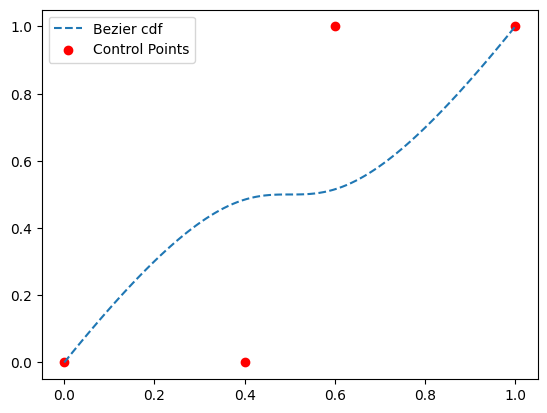

In [4]:
bz.plot_cdf()

In [5]:
random_samples = bz.random(1000, rng=42)

(array([1.86237883, 1.38176494, 2.07264741, 1.53195678, 1.26161147,
        1.26161147, 1.35172657, 0.87111268, 0.93118942, 0.84107431,
        0.72092084, 0.60076737, 0.33042205, 0.0901151 , 0.        ,
        0.        , 0.18023021, 0.30038368, 0.51065226, 0.60076737,
        0.78099758, 1.11141963, 1.17149636, 1.08138126, 1.26161147,
        1.68214862, 1.41180331, 1.59203352, 1.65211026, 1.59203352]),
 array([7.40040511e-04, 3.40307969e-02, 6.73215532e-02, 1.00612310e-01,
        1.33903066e-01, 1.67193822e-01, 2.00484579e-01, 2.33775335e-01,
        2.67066091e-01, 3.00356848e-01, 3.33647604e-01, 3.66938360e-01,
        4.00229117e-01, 4.33519873e-01, 4.66810630e-01, 5.00101386e-01,
        5.33392142e-01, 5.66682899e-01, 5.99973655e-01, 6.33264411e-01,
        6.66555168e-01, 6.99845924e-01, 7.33136680e-01, 7.66427437e-01,
        7.99718193e-01, 8.33008950e-01, 8.66299706e-01, 8.99590462e-01,
        9.32881219e-01, 9.66171975e-01, 9.99462731e-01]),
 <BarContainer object of 30 

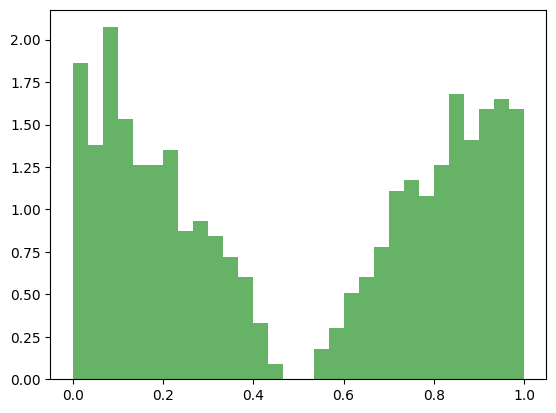

In [6]:
plt.hist(random_samples, bins=30, density=True, alpha=0.6, color='g')

In [7]:
# use distfit to fit a distribution to the random samples
fitter = DistFit(random_samples, n=3, method_init_x='uniform')
bz_hat, mse = fitter.fit(method='mse', algorithm='nonlinear')

ERROR: Solver (ipopt) returned non-zero return code (3221225477)


RuntimeError: Nonlinear solver 'ipopt' failed while fitting the Bezierv model. This usually means the solver binary crashed or is misconfigured. Try a different algorithm such as 'projgrad' or repair the solver installation.

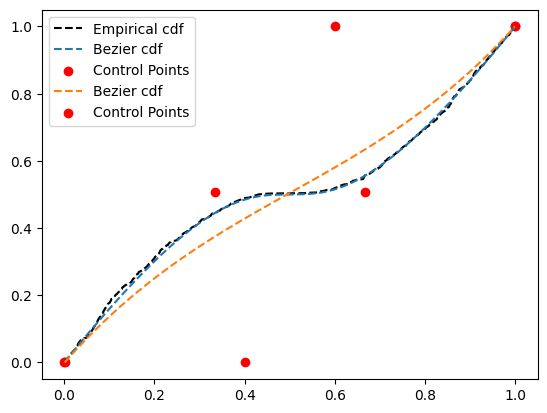

In [ ]:
# plot bz and bz_hat cdf on the same plot
fig, ax = plt.subplots()
bz.plot_cdf(ax=ax, show=False, data=random_samples)
bz_hat.plot_cdf(ax=ax, show=False)